In [4]:
import struct
import sys
import torchvision
import torch
import json
from array import array
from os import path

train_dataset = torchvision.datasets.MNIST(root='/content/sample_data/', train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root='/content/sample_data/', train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 355kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.37MB/s]


In [5]:
import os
import struct
import numpy as np
from array import array
from os import path
from PIL import Image

def read(dataset):
    if dataset == "training":
        path_img = "/content/sample_data/MNIST/raw/train-images-idx3-ubyte"
        path_lbl = "/content/sample_data/MNIST/raw/train-labels-idx1-ubyte"
    elif dataset == "testing":
        path_img = "/content/sample_data/MNIST/raw/t10k-images-idx3-ubyte"
        path_lbl = "/content/sample_data/MNIST/raw/t10k-labels-idx1-ubyte"
    else:
        raise ValueError("dataset must be 'testing' or 'training'")

    with open(path_lbl, 'rb') as f_label:
        _, size = struct.unpack(">II", f_label.read(8))
        lbl = array("B", f_label.read())

    with open(path_img, 'rb') as f_img:
        _, size, rows, cols = struct.unpack(">IIII", f_img.read(16))
        img = array("B", f_img.read())

    return lbl, img, size, rows, cols


def write_dataset(labels, data, size, rows, cols, output_dir):
    # создаём папки class_0 ... class_9
    for c in range(10):
        os.makedirs(path.join(output_dir, f"class_{c}"), exist_ok=True)

    # весь массив пикселей -> [size, rows, cols]
    imgs = np.frombuffer(data, dtype=np.uint8).reshape(size, rows, cols)

    # каждую картинку сохраняем в папку её класса
    for i, label in enumerate(labels):
        out = path.join(output_dir, f"class_{label}", f"{i}.png")
        Image.fromarray(imgs[i]).save(out)


output_path = "/content/mnist"

for dataset in ["training", "testing"]:
    write_dataset(*read(dataset), path.join(output_path, dataset))

In [6]:
if not os.path.isdir("dataset"):
    os.mkdir("dataset")

img = np.random.randint(0, 50, [100000, 64, 64], dtype=np.uint8)
square = np.random.randint(100, 200, [100000, 15, 15], dtype=np.uint8)

coords = np.empty([100000, 2])

data = {}

for i in range(img.shape[0]):

    x = np.random.randint(20, 44)
    y = np.random.randint(20, 44)

    img[i,(y-7):(y +8), (x -7):(x + 8)] = square[i]

    coords[i] = [y, x]

    name_img = f'img_{i}.jpeg'
    path_img = os.path. join('dataset/', name_img)

    image = Image. fromarray(img[i])
    image. save(path_img)

    data[name_img] = [y, x]

with open('dataset/coords.json', 'w') as f:
    json.dump(data, f, indent=2)

# os.rmdir('dataset/.ipynb_checkpoints')

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

import json
from tqdm import tqdm
from PIL import Image

In [8]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input, 128),
            nn.ReLU(),
            nn.Linear(128, output)
        )

    def forward(self, x):
        return self.model(x)

LR Scheduler нужен чтобы изменять скорость обучения во время обучения.

### LambdaLR
В каждом шедулере есть счетчик, который равен 0. Но при каждом вызове метода step(), он увеличивается на 1 и передается в указанную функцию, которая обрабатывает нужным способом. В данном примере ф-ия при каждом 10 вызове будет возвращать 0.1 вместо 1.

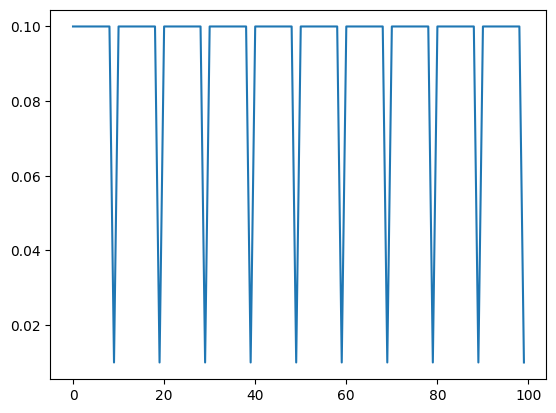

In [9]:
model = MyModel(784, 10)
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.1)

# -------------------------------------------------------------------------
lr_lambda = lambda step: 0.1 if step%10==0 else 1
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)
# -------------------------------------------------------------------------

list_ = []
for epoch in range(100):
    # Train
    for i in range(1):
        # forward
        # backward
        opt.step()

    # Validaiton
        # forward

    lr_scheduler.step()
    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)

На каждой 10 эпохе скорость обучения lr_lambda = 0.1 умножалось на скорость обучения lr=0.1. На следующей эпохе ф-ия вернула 1, которая была умножена на 0.1


### Multistep LR
Снижает lr в Х раз на конкретно заданных эпохах

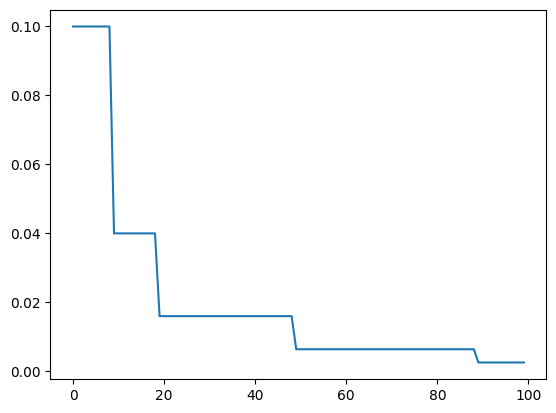

In [10]:
model = MyModel(784, 10)
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.1)

# -------------------------------------------------------------------------
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[10,20,50,90], gamma=0.4)
# -------------------------------------------------------------------------

list_ = []
for epoch in range(100):
    # Train
    for i in range(1):
        # forward
        # backward
        opt.step()

    # Validaiton
        # forward

    lr_scheduler.step()
    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)

### StepLR
Тоже самое, что и MultiStep, но здесь надо указывать через какое кол-во итераций менять скорость обучения

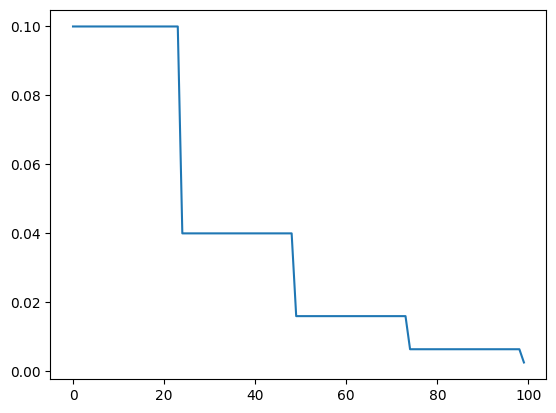

In [11]:
model = MyModel(784, 10)
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.1)

# -------------------------------------------------------------------------
lr_scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=25, gamma=0.4)
# -------------------------------------------------------------------------

list_ = []
for epoch in range(100):
    # Train
    for i in range(1):
        # forward
        # backward
        opt.step()

    # Validaiton
        # forward

    lr_scheduler.step()
    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)

### Exponential LR
При каждом вызове step (каждая эпоха), lr умножается на коэф gamma

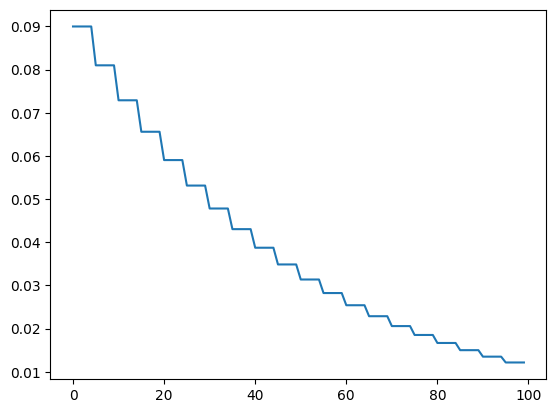

In [12]:
model = MyModel(784, 10)
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.1)

# -------------------------------------------------------------------------
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
# -------------------------------------------------------------------------

list_ = []
for epoch in range(100):
    # Train
    for i in range(1):
        # forward
        # backward
        opt.step()

    # Validaiton
        # forward

    # lr_scheduler.step()
    if epoch%5==0:
        lr_scheduler.step()
    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)

### Reduce LR On Plateau
Следит за выбранной метрикой (например, val_loss), и если метрика перестает улучшаться в течение заданного количества эпох, планировщик снижает lr.

In [13]:
model = MyModel(784, 10)
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.1)

# -------------------------------------------------------------------------
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,
                                                          mode='min', # max/min - следим за увел/уменьш отслеживаемого параметра
                                                          factor=0.1, # коэф, на который умножается lr
                                                          patience=10, # кол-во эпох без улучшения отслеживаемого параметра
                                                          threshold=0.0001, # порог увеличения отслеживаемого параметра, чтобы не происходила корректировка
                                                          threshold_mode='rel', # rel/abs - если rel, то отслеж. параметр изменяется на проценты, если abs - то просто на число
                                                          cooldown=0, # кол-во периодов ожидания после изменения lr
                                                          min_lr=0, # мин. значение скорости обучение
                                                          eps=1e-8) # мин. изменение между новым и старым lr
# -------------------------------------------------------------------------

loss = torch.full([5,10],0.1)
loss = loss * torch.tensor([1/i for i in range(1,6)]).reshape([5,1])
loss = loss.reshape([50])

list_ = []
for epoch in range(50):
    # Train
    for i in range(1):
        # forward
        # backward
        opt.step()

    # Validaiton
        # forward

    idx = epoch
    lr_scheduler.step(loss[idx])
    lr = lr_scheduler._last_lr[0]
    list_.append(lr)

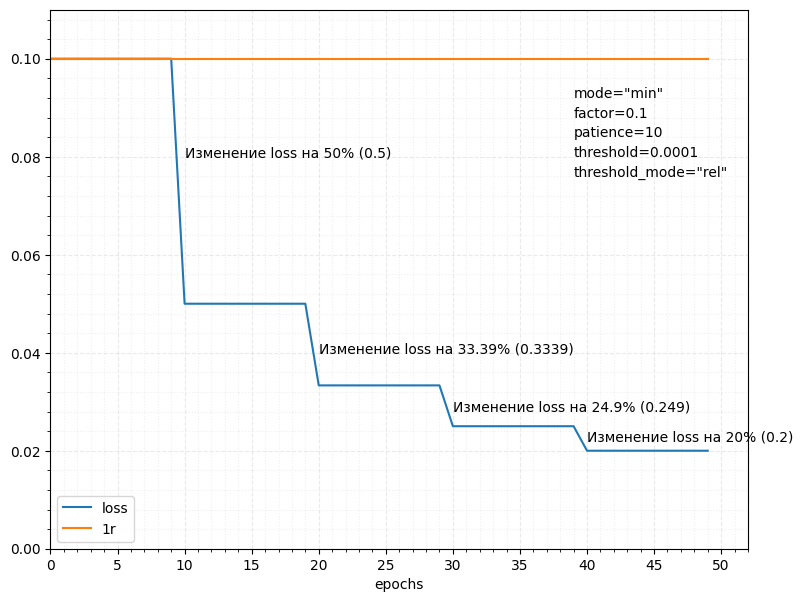

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(loss)
ax.plot(list_)

ax.set_xlim(0, 52)
ax.set_ylim(0, 0.11)

ax.xaxis.set_major_locator(MultipleLocator(5))

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(which='major', color='#CCCCCC', linestyle='--', alpha=0.4)
ax.grid(which='minor', color='#CCCCCC', linestyle=':', alpha=0.3)

ax.legend(["loss", "1r"])
ax.set_xlabel('epochs')

if lr_scheduler.threshold_mode == "abs":
    ax.text(10, 0.08, 'Изменение loss нa 0.05')
    ax.text(20, 0.04, 'Изменение loss на 0.0167')
    ax.text(30, 0.028, 'Изменение loss на 0.008')
    ax.text(40, 0.022, 'змеHениe loss на 0.005')
else:
    ax.text(10, 0.08, 'Изменение loss нa 50% (0.5)')
    ax.text(20, 0.04, 'Изменение loss на 33.39% (0.3339)')
    ax.text(30, 0.028, 'Изменение loss на 24.9% (0.249)')
    ax.text(40, 0.022, 'Изменение loss на 20% (0.2)')

ax.text(39, 0.092, f'mode="{lr_scheduler.mode}"')
ax.text(39, 0.088, f'factor={lr_scheduler.factor}')
ax.text(39, 0.084, f'patience={lr_scheduler.patience}')
ax.text(39, 0.080, f'threshold={lr_scheduler.threshold}')
ax.text(39, 0.076, f'threshold_mode="{lr_scheduler.threshold_mode}"')

plt.show()

### Проверим на практике

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [16]:
class DataReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self. len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as f:
            self.dict_coords = json.load((f))

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = np.array(Image.open(path_img))
        coord = np.array(self.dict_coords[name_file])

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [17]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,),std=(0.5,))
    ]
)

In [18]:
dataset = DataReg(r'/content/dataset', transform=transform)

In [19]:
train, val, test = random_split(dataset, [0.7,0.1,0.2])

In [20]:
train_loader = DataLoader(train, 16, True)
val_loader = DataLoader(val, 16, False)
test_loader = DataLoader(test, 16, False)

In [21]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(64*64, 2).to(device)

In [22]:
input = torch.rand([16,64*64], dtype=torch.float32).to(device)
out = model(input)
out.shape

torch.Size([16, 2])

In [23]:
loss_model = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,
                                                          mode='min',
                                                          factor=0.1,
                                                          patience=5)

In [24]:
EPOCHS = 15

train_loss = []
val_loss = []
train_acc = []
val_acc = []
lr_list = []
best_loss = None

In [32]:
for epoch in range(EPOCHS):

    model.train()
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)
    for x, targets in train_loop:
        x = x.reshape(-1, 64 * 64).to(device)
        targets = targets.to(device).float()

        # Прямой проход + ошибка
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()

        # Шаг оптимизации
        opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)
        true_answer += (pred.round() == targets).all(dim=1).sum().item()
        train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}')

    running_train_acc = true_answer / len(train)
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            x = x.reshape(-1, 64 * 64).to(device)
            targets = targets.to(device).float()

            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            true_answer += (pred.round() == targets).all(dim=1).sum().item()

        mean_val_loss = sum(running_val_loss) / len(running_val_loss)
        running_val_acc = true_answer / len(val)

        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

    lr_scheduler.step(mean_val_loss)
    lr = lr_scheduler._last_lr[0]
    lr_list.append(lr)

    print(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}, train_acc: {running_train_acc:.4f}, val_loss: {mean_val_loss:.4f}, val_acc: {running_val_acc:.4f}, lr: {lr:.4f}')

    if best_loss is None:
        best_loss = mean_val_loss

    if mean_val_loss < best_loss:
        best_loss = mean_val_loss

        torch.save(model.state_dict(), f'model_state_dict_epoch_{epoch+1}.pt')
        print(f'На эпохе {epoch+1} сохранена модель со значением ф-ии потерь на валидации: {mean_val_loss:.4f}', end='\n\n')

Epoch: [1/15], train_loss: 0.0529, train_acc: 0.9385, val_loss: 0.0475, val_acc: 0.9499, lr: 0.0010


Epoch: [2/15], train_loss: 0.0531, train_acc: 0.9359, val_loss: 0.0398, val_acc: 0.9748, lr: 0.0010


Epoch: [3/15], train_loss: 0.0518, train_acc: 0.9434, val_loss: 0.0623, val_acc: 0.9103, lr: 0.0010


Epoch: [4/15], train_loss: 0.0514, train_acc: 0.9434, val_loss: 0.0426, val_acc: 0.9663, lr: 0.0010


Epoch: [5/15], train_loss: 0.0506, train_acc: 0.9467, val_loss: 0.0485, val_acc: 0.9528, lr: 0.0010


...

Epoch: [11/15], train_loss: 0.0290, train_acc: 0.9916, val_loss: 0.0339, val_acc: 0.9833, lr: 0.0001


Epoch: [12/15], train_loss: 0.0286, train_acc: 0.9920, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0001
На эпохе 12 сохранена модель со значением ф-ии потерь на валидации: 0.0327



Epoch: [13/15], train_loss: 0.0284, train_acc: 0.9921, val_loss: 0.0333, val_acc: 0.9853, lr: 0.0001


Epoch: [14/15], train_loss: 0.0284, train_acc: 0.9919, val_loss: 0.0430, val_acc: 0.9679, lr: 0.0001


Epoch: [15/15], train_loss: 0.0284, train_acc: 0.9921, val_loss: 0.0345, val_acc: 0.9819, lr: 0.0001


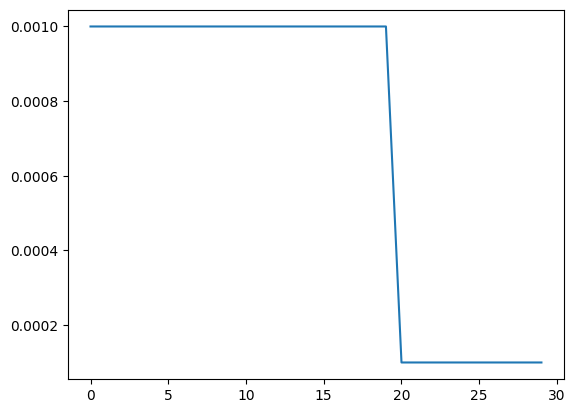

In [33]:
plt.plot(lr_list)

/tmp/ipykernel_2324/1799940628.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


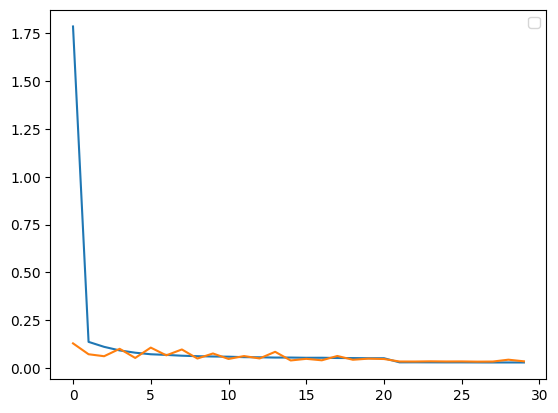

In [34]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend()

/tmp/ipykernel_2324/1309107087.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


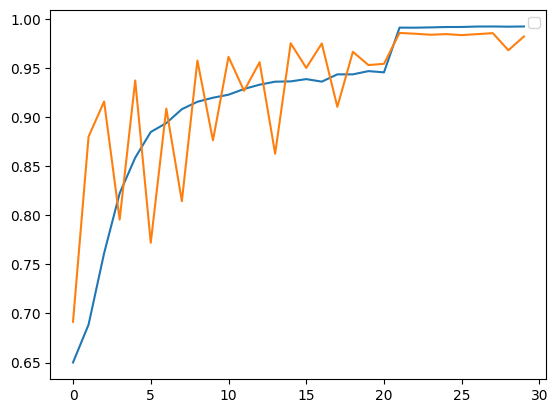

In [35]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend()

### Сохранение

In [36]:
# Сохранение: torch.save(object, PATH)

# Загрузка: torch.load(PATH)

# Если модель показывает лучший результат на какой-то эпохе, то ее надо сохранять

### Загрузка модели

In [37]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [38]:
param_model = torch.load(r'/content/model_state_dict_epoch_12.pt')
param_model

# Если мы будем загружать модель на другом процессоре, нужно будет указать map_location=device

OrderedDict([('layer_1.weight',
              tensor([[-0.0014,  0.0077,  0.0015,  ..., -0.0073,  0.0052,  0.0215],
                      [ 0.0167, -0.0020, -0.0017,  ...,  0.0145,  0.0032, -0.0030],
                      [ 0.0020,  0.0043, -0.0010,  ..., -0.0058,  0.0013,  0.0176],
                      ...,
                      [-0.0200, -0.0245, -0.0222,  ...,  0.0038, -0.0168, -0.0215],
                      [ 0.0119, -0.0050,  0.0003,  ...,  0.0093,  0.0139, -0.0072],
                      [-0.0177,  0.0114, -0.0087,  ..., -0.0014, -0.0098, -0.0023]],
                     device='cuda:0')),
             ('layer_1.bias',
              tensor([-1.3275e-02,  7.4811e-03,  6.5953e-05,  1.3202e-02,  6.6296e-04,
                      -2.0449e-02, -1.7178e-02, -1.3114e-02, -3.6580e-03,  9.1852e-03,
                       9.5928e-03,  3.4431e-04,  3.3003e-02,  3.4685e-03, -9.0569e-03,
                      -1.9428e-02, -1.8345e-02,  1.1186e-02,  7.0665e-04, -1.3675e-03,
                  

In [39]:
new_model = MyModel(64*64, 2).to(device)

In [40]:
new_model.load_state_dict(param_model)

<All keys matched successfully>

In [41]:
new_model.eval()
with torch.no_grad():
    run_val_loss = []
    true_answer = 0
    for x, targets in val_loader:
        x = x.reshape(-1,64*64).to(device)
        targets = targets.to(device)

        pred = new_model(x)
        loss = loss_model(pred, targets)

        run_val_loss.append(loss.item())
        mean_val_loss = sum(run_val_loss)/len(run_val_loss)

        true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

    run_val_acc = true_answer / len(val)

print(f'val_los = {mean_val_loss:.4f}, val_acc = {run_val_acc:.4f}')

val_los = 0.0327, val_acc = 0.9843


Epoch: [12/15], train_loss: 0.0609, train_acc: 0.9164, val_loss: 0.0469, val_acc: 0.9578, lr: 0.0010

Значения совпали, значит, файл сохранился правильно

Вариант сохранения модели с возможностью последующего дообучения

Для этого надо создать собственный словарь, с нужной информацией

In [42]:
str_info = '''
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(64*64, 2)
'''
EPOCHS = 30
save_epoch = 14
best_loss = None

In [43]:
checkpoint = {
    'info': str_info,
    'state_model': model.state_dict(),
    'state_opt': opt.state_dict(),
    'state_lr_scheduler': lr_scheduler.state_dict(),
    'loss': {
        'train_loss': train_loss,
        'val_loss': val_loss,
        'best_loss': best_loss
    },
    'metric':{
        'train_acc': train_acc,
        'val_acc': val_acc
    },
    'lr': lr_list,
    'epoch':{
        'EPOCHS': EPOCHS,
        'save_epoch': save_epoch
    }
}

torch.save(checkpoint, 'model_state_dict_checkpoint.pt')

In [44]:
load_model_state = torch.load('model_state_dict_checkpoint.pt')

In [45]:
print(load_model_state['info'])


class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(64*64, 2)



Все получилось. Мы получили словарь, который сохраняли

In [46]:
# Создание модели
new_model_1 = MyModel(64*64, 2).to(device)

loss_model = nn.MSELoss()
new_opt = torch.optim.Adam(new_model_1.parameters(), lr=0.001)
new_lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(new_opt)

In [47]:
new_model_1.load_state_dict(load_model_state['state_model'])
new_opt.load_state_dict(load_model_state['state_opt'])
new_lr_scheduler.load_state_dict(load_model_state['state_lr_scheduler'])

In [48]:
EPOCHS = load_model_state['epoch']['EPOCHS']
save_epoch = load_model_state['epoch']['save_epoch']

train_loss = load_model_state['loss']['train_loss']
train_acc = load_model_state['metric']['train_acc']
val_loss = load_model_state['loss']['val_loss']
val_acc = load_model_state['metric']['val_acc']
lr_list = load_model_state['lr']
best_loss = load_model_state['loss']['best_loss']

for epoch in range(save_epoch+1, EPOCHS):

    # Тренировка
    new_model_1.train()
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)
    for x, targets in train_loop:
        x = x.reshape(-1, 64 * 64).to(device)
        targets = targets.to(device).float()

        # Прямой проход + ошибка
        pred = new_model_1(x)
        loss = loss_model(pred, targets)
        # Обратный проход
        new_opt.zero_grad()
        loss.backward()
        # Шаг оптимизации
        new_opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)

        true_answer += (pred.round() == targets).all(dim=1).sum().item()
        train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}')

    running_train_acc = true_answer / len(train)
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    new_model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            x = x.reshape(-1, 64 * 64).to(device)
            targets = targets.to(device).float()

            pred = new_model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss) / len(running_val_loss)

            true_answer += (pred.round() == targets).all(dim=1).sum().item()

        running_val_acc = true_answer / len(val)

        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

    new_lr_scheduler.step(mean_val_loss)
    lr = new_lr_scheduler._last_lr[0]
    lr_list.append(lr)

    print(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}, train_acc: {running_train_acc:.4f}, val_loss: {mean_val_loss:.4f}, val_acc: {running_val_acc:.4f}, lr: {lr:.4f}')

    if best_loss is None:
        best_loss = mean_val_loss

    if mean_val_loss < best_loss:
        best_loss = mean_val_loss

        checkpoint = {
            'info': str_info,
            'state_model': model.state_dict(),
            'state_opt': opt.state_dict(),
            'state_lr_scheduler': lr_scheduler.state_dict(),
            'loss': {
                'train_loss': train_loss,
                'val_loss': val_loss,
                'best_loss': best_loss
            },
            'metric':{
                'train_acc': train_acc,
                'val_acc': val_acc
            },
            'lr': lr_list,
            'epoch':{
                'EPOCHS': EPOCHS,
                'save_epoch': save_epoch
            }
        }

        torch.save(model.state_dict(), f'model_state_dict_epoch_{epoch+1}.pt')
        print(f'На эпохе {epoch+1} сохранена модель со значением ф-ии потерь на валидации: {mean_val_loss:.4f}', end='\n\n')


Epoch: [16/30], train_loss: 0.0284, train_acc: 0.9922, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0001


Epoch: [17/30], train_loss: 0.0282, train_acc: 0.9927, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0001


Epoch: [18/30], train_loss: 0.0280, train_acc: 0.9932, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


Epoch: [19/30], train_loss: 0.0255, train_acc: 0.9951, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


Epoch: [20/30], train_loss: 0.0254, train_acc: 0.9954, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


...

Epoch: [26/30], train_loss: 0.0251, train_acc: 0.9955, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


Epoch: [27/30], train_loss: 0.0251, train_acc: 0.9955, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


Epoch: [28/30], train_loss: 0.0250, train_acc: 0.9956, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


Epoch: [29/30], train_loss: 0.0251, train_acc: 0.9956, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


Epoch: [30/30], train_loss: 0.0251, train_acc: 0.9955, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0000


Epoch: [12/15], train_loss: 0.0286, train_acc: 0.9920, val_loss: 0.0327, val_acc: 0.9843, lr: 0.0001

Вот такие результаты получились